#Introduction

## Dataset Overview

This dataset contains historical U.S. economic and Federal Reserve
interest-rate data beginning in 1954.

### Key Variables

- **Effective Federal Funds Rate:** The actual average interest rate banks charge each other for overnight loans of excess reserves.

- **Federal Funds Target Rate:** The Federal Reserve's target for the
  federal funds rate. Beginning in December 2008, the single target rate
  was replaced by a target range with upper and lower bounds.

- **Real GDP (% Change):** Seasonally adjusted quarterly percentage
  change in real U.S. gross domestic product.

- **Unemployment Rate:** Seasonally adjusted percentage of the labor
  force that is unemployed.

- **Inflation Rate:** Inflation measure based on the Consumer Price
  Index excluding food and energy.

### Data Sources

The dataset combines economic data originally published by:
- Federal Reserve Bank of St. Louis
- U.S. Bureau of Economic Analysis
- U.S. Bureau of Labor Statistics

## Business Objective

Analyze historical U.S. economic conditions to understand how Federal
Reserve interest-rate policy relates to inflation, unemployment, and
economic growth.

Key questions include:

1. How have inflation, unemployment, GDP growth, and interest rates
   changed over time?
2. What relationships exist between these economic indicators and
   federal funds rates?
3. How has Federal Reserve interest-rate policy changed across
   different economic periods?
4. Which historical periods experienced unusually high or low values?

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving index.csv to index.csv


In [ ]:
df = pd.read_csv("index.csv")
df

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate
0,1954,7,1,NaN,NaN,NaN,0.80,4.6,5.8,NaN
1,1954,8,1,NaN,NaN,NaN,1.22,NaN,6.0,NaN
2,1954,9,1,NaN,NaN,NaN,1.06,NaN,6.1,NaN
3,1954,10,1,NaN,NaN,NaN,0.85,8.0,5.7,NaN
4,1954,11,1,NaN,NaN,NaN,0.83,NaN,5.3,NaN
...,...,...,...,...,...,...,...,...,...,...
899,2016,12,14,NaN,0.75,0.50,NaN,NaN,NaN,NaN
900,2017,1,1,NaN,0.75,0.50,0.65,NaN,4.8,2.3
901,2017,2,1,NaN,0.75,0.50,0.66,NaN,4.7,2.2
902,2017,3,1,NaN,0.75,0.50,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate
0,1954,7,1,NaN,NaN,NaN,0.80,4.6,5.8,NaN
1,1954,8,1,NaN,NaN,NaN,1.22,NaN,6.0,NaN
2,1954,9,1,NaN,NaN,NaN,1.06,NaN,6.1,NaN
3,1954,10,1,NaN,NaN,NaN,0.85,8.0,5.7,NaN
4,1954,11,1,NaN,NaN,NaN,0.83,NaN,5.3,NaN


In [ ]:
df.tail()

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate
899,2016,12,14,NaN,0.75,0.50,NaN,NaN,NaN,NaN
900,2017,1,1,NaN,0.75,0.50,0.65,NaN,4.8,2.3
901,2017,2,1,NaN,0.75,0.50,0.66,NaN,4.7,2.2
902,2017,3,1,NaN,0.75,0.50,NaN,NaN,NaN,NaN
903,2017,3,16,NaN,1.00,0.75,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(904, 10)

###Checking Missing Values

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Federal Funds Target Rate,442
Federal Funds Upper Target,801
Federal Funds Lower Target,801
Effective Federal Funds Rate,152
Real GDP (Percent Change),654
Unemployment Rate,152
Inflation Rate,194


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          904 non-null    int64  
 1   Month                         904 non-null    int64  
 2   Day                           904 non-null    int64  
 3   Federal Funds Target Rate     462 non-null    float64
 4   Federal Funds Upper Target    103 non-null    float64
 5   Federal Funds Lower Target    103 non-null    float64
 6   Effective Federal Funds Rate  752 non-null    float64
 7   Real GDP (Percent Change)     250 non-null    float64
 8   Unemployment Rate             752 non-null    float64
 9   Inflation Rate                710 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 70.8 KB


In [ ]:
df.dtypes

,0
Year,int64
Month,int64
Day,int64
Federal Funds Target Rate,float64
Federal Funds Upper Target,float64
Federal Funds Lower Target,float64
Effective Federal Funds Rate,float64
Real GDP (Percent Change),float64
Unemployment Rate,float64
Inflation Rate,float64


###Checking Duplicated Values

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
899,False
900,False
901,False
902,False


In [ ]:
df.duplicated().sum()

np.int64(0)

###Create a Date Column

In [ ]:
df['Date'] = pd.to_datetime(df[['Year','Month','Day']])
print(df)

     Year  Month  Day  Federal Funds Target Rate  Federal Funds Upper Target  \
0    1954      7    1                        NaN                         NaN   
1    1954      8    1                        NaN                         NaN   
2    1954      9    1                        NaN                         NaN   
3    1954     10    1                        NaN                         NaN   
4    1954     11    1                        NaN                         NaN   
..    ...    ...  ...                        ...                         ...   
899  2016     12   14                        NaN                        0.75   
900  2017      1    1                        NaN                        0.75   
901  2017      2    1                        NaN                        0.75   
902  2017      3    1                        NaN                        0.75   
903  2017      3   16                        NaN                        1.00   

     Federal Funds Lower Target  Effect

In [ ]:
df.dtypes

,0
Year,int64
Month,int64
Day,int64
Federal Funds Target Rate,float64
Federal Funds Upper Target,float64
Federal Funds Lower Target,float64
Effective Federal Funds Rate,float64
Real GDP (Percent Change),float64
Unemployment Rate,float64
Inflation Rate,float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date
count,904.000000,904.000000,904.000000,462.000000,103.000000,103.000000,752.000000,250.000000,752.000000,710.000000,904
mean,1986.680310,6.598451,3.598451,5.658415,0.308252,0.058252,4.910997,3.138000,5.979122,3.733380,1987-02-25 15:54:09.557522112
min,1954.000000,1.000000,1.000000,1.000000,0.250000,0.000000,0.070000,-10.000000,3.400000,0.600000,1954-07-01 00:00:00
25%,1973.000000,4.000000,1.000000,3.750000,0.250000,0.000000,2.427500,1.400000,4.900000,2.000000,1973-04-23 12:00:00
50%,1987.500000,7.000000,1.000000,5.500000,0.250000,0.000000,4.700000,3.100000,5.700000,2.800000,1987-12-16 12:00:00
75%,2001.000000,10.000000,1.000000,7.750000,0.250000,0.000000,6.580000,4.875000,7.000000,4.700000,2001-06-07 12:00:00
max,2017.000000,12.000000,31.000000,11.500000,1.000000,0.750000,19.100000,16.500000,10.800000,13.600000,2017-03-16 00:00:00
std,17.172843,3.471963,6.791079,2.553891,0.140917,0.140917,3.611431,3.598521,1.567641,2.573637,NaN


In [ ]:
df = pd.read_csv("index.csv")

df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

###Check Percentage of Missing Values For Each Column

In [ ]:
Formula = (442 / 904) * 100
Formula

48.89380530973451

In [ ]:
Percent_of_missing_values = (df.isnull().sum()/len(df)) * 100
Percent_of_missing_values

,0
Year,0.000000
Month,0.000000
Day,0.000000
Federal Funds Target Rate,48.893805
Federal Funds Upper Target,88.606195
Federal Funds Lower Target,88.606195
Effective Federal Funds Rate,16.814159
Real GDP (Percent Change),72.345133
Unemployment Rate,16.814159
Inflation Rate,21.460177


###Investigate Missing Values

In [ ]:
historical_period = df[df['Federal Funds Target Rate'].notna()]

historical_period

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date
339,1982,9,27,10.25,NaN,NaN,NaN,NaN,NaN,NaN,1982-09-27
340,1982,10,1,10.00,NaN,NaN,9.71,0.4,10.4,5.9,1982-10-01
341,1982,10,7,9.50,NaN,NaN,NaN,NaN,NaN,NaN,1982-10-07
342,1982,11,1,9.50,NaN,NaN,9.20,NaN,10.8,5.3,1982-11-01
343,1982,11,19,9.00,NaN,NaN,NaN,NaN,NaN,NaN,1982-11-19
...,...,...,...,...,...,...,...,...,...,...,...
796,2008,10,1,2.00,NaN,NaN,0.97,-8.2,6.5,2.2,2008-10-01
797,2008,10,8,1.50,NaN,NaN,NaN,NaN,NaN,NaN,2008-10-08
798,2008,10,29,1.00,NaN,NaN,NaN,NaN,NaN,NaN,2008-10-29
799,2008,11,1,1.00,NaN,NaN,0.39,NaN,6.8,2.0,2008-11-01


In [ ]:
historical_period = df[df['Federal Funds Target Rate'].notna()][
    ['Date', 'Federal Funds Target Rate']
]

historical_period

,Date,Federal Funds Target Rate
339,1982-09-27,10.25
340,1982-10-01,10.00
341,1982-10-07,9.50
342,1982-11-01,9.50
343,1982-11-19,9.00
...,...,...
796,2008-10-01,2.00
797,2008-10-08,1.50
798,2008-10-29,1.00
799,2008-11-01,1.00


In [ ]:
historical_period.head()

,Date,Federal Funds Target Rate
339,1982-09-27,10.25
340,1982-10-01,10.00
341,1982-10-07,9.50
342,1982-11-01,9.50
343,1982-11-19,9.00


In [ ]:
historical_period.tail()

,Date,Federal Funds Target Rate
796,2008-10-01,2.0
797,2008-10-08,1.5
798,2008-10-29,1.0
799,2008-11-01,1.0
800,2008-12-01,1.0


In [ ]:
upper_period = df[df['Federal Funds Upper Target'].notna()][
    ['Date', 'Federal Funds Upper Target']
]
upper_period

,Date,Federal Funds Upper Target
801,2008-12-16,0.25
802,2009-01-01,0.25
803,2009-02-01,0.25
804,2009-03-01,0.25
805,2009-04-01,0.25
...,...,...
899,2016-12-14,0.75
900,2017-01-01,0.75
901,2017-02-01,0.75
902,2017-03-01,0.75


In [ ]:
lower_period = df[df['Federal Funds Lower Target'].notna()][
    ['Date', 'Federal Funds Lower Target']
]
lower_period

,Date,Federal Funds Lower Target
801,2008-12-16,0.00
802,2009-01-01,0.00
803,2009-02-01,0.00
804,2009-03-01,0.00
805,2009-04-01,0.00
...,...,...
899,2016-12-14,0.50
900,2017-01-01,0.50
901,2017-02-01,0.50
902,2017-03-01,0.50


In [ ]:
Real_GDP = df[df['Real GDP (Percent Change)'].notna()][
    ['Date', 'Real GDP (Percent Change)']
]
Real_GDP

,Date,Real GDP (Percent Change)
0,1954-07-01,4.6
3,1954-10-01,8.0
6,1955-01-01,11.9
9,1955-04-01,6.7
12,1955-07-01,5.5
...,...,...
883,2015-10-01,0.9
887,2016-01-01,0.8
890,2016-04-01,1.4
893,2016-07-01,3.5


In [ ]:
unemployment = df[df['Unemployment Rate'].notna()][
    ['Date', 'Unemployment Rate']
]
unemployment

,Date,Unemployment Rate
0,1954-07-01,5.8
1,1954-08-01,6.0
2,1954-09-01,6.1
3,1954-10-01,5.7
4,1954-11-01,5.3
...,...,...
896,2016-10-01,4.8
897,2016-11-01,4.6
898,2016-12-01,4.7
900,2017-01-01,4.8


In [ ]:
Inflation_Rate = df[df['Inflation Rate'].notna()][['Date','Inflation Rate']]
Inflation_Rate

,Date,Inflation Rate
42,1958-01-01,3.2
43,1958-02-01,3.2
44,1958-03-01,2.8
45,1958-04-01,2.4
46,1958-05-01,2.4
...,...,...
896,2016-10-01,2.1
897,2016-11-01,2.1
898,2016-12-01,2.2
900,2017-01-01,2.3


In [ ]:
effective_rate = df[df['Effective Federal Funds Rate'].notna()][
    ['Date', 'Effective Federal Funds Rate']
]
effective_rate

,Date,Effective Federal Funds Rate
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.06
3,1954-10-01,0.85
4,1954-11-01,0.83
...,...,...
896,2016-10-01,0.40
897,2016-11-01,0.41
898,2016-12-01,0.54
900,2017-01-01,0.65


###Clean Up

In [ ]:
df['Federal Funds'] = np.where(df['Federal Funds Target Rate'].notna(),df['Federal Funds Target Rate'],(df['Federal Funds Upper Target']+df['Federal Funds Lower Target'])/2)

In [ ]:
df[[
    'Date',
    'Federal Funds Target Rate',
    'Federal Funds Upper Target',
    'Federal Funds Lower Target',
    'Federal Funds'
]]

,Date,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Federal Funds
0,1954-07-01,NaN,NaN,NaN,NaN
1,1954-08-01,NaN,NaN,NaN,NaN
2,1954-09-01,NaN,NaN,NaN,NaN
3,1954-10-01,NaN,NaN,NaN,NaN
4,1954-11-01,NaN,NaN,NaN,NaN
...,...,...,...,...,...
899,2016-12-14,NaN,0.75,0.50,0.625
900,2017-01-01,NaN,0.75,0.50,0.625
901,2017-02-01,NaN,0.75,0.50,0.625
902,2017-03-01,NaN,0.75,0.50,0.625


In [ ]:
transition_period = df[
    (df['Date'] >= '2008-10-01') &
    (df['Date'] <= '2009-02-01')
]

In [ ]:
transition_period[[
    'Date',
    'Federal Funds Target Rate',
    'Federal Funds Upper Target',
    'Federal Funds Lower Target',
    'Federal Funds'
]]

,Date,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Federal Funds
796,2008-10-01,2.0,NaN,NaN,2.000
797,2008-10-08,1.5,NaN,NaN,1.500
798,2008-10-29,1.0,NaN,NaN,1.000
799,2008-11-01,1.0,NaN,NaN,1.000
800,2008-12-01,1.0,NaN,NaN,1.000
801,2008-12-16,NaN,0.25,0.0,0.125
802,2009-01-01,NaN,0.25,0.0,0.125
803,2009-02-01,NaN,0.25,0.0,0.125


In [ ]:
df = df.drop(columns=[
    'Federal Funds Target Rate',
    'Federal Funds Upper Target',
    'Federal Funds Lower Target'
])

In [ ]:
df = df.drop(columns=[
    'Year',
    'Month',
    'Day'
])

In [ ]:
df.rename(columns={
    'Federal Funds': 'Federal Funds Target Rate'
}, inplace=True)

In [ ]:
df.columns

Index(['Effective Federal Funds Rate', 'Real GDP (Percent Change)',
       'Unemployment Rate', 'Inflation Rate', 'Date',
       'Federal Funds Target Rate'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Effective Federal Funds Rate  752 non-null    float64       
 1   Real GDP (Percent Change)     250 non-null    float64       
 2   Unemployment Rate             752 non-null    float64       
 3   Inflation Rate                710 non-null    float64       
 4   Date                          904 non-null    datetime64[ns]
 5   Federal Funds Target Rate     565 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 42.5 KB


In [ ]:
df.describe()

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
count,752.000000,250.000000,752.000000,710.000000,904,565.000000
mean,4.910997,3.138000,5.979122,3.733380,1987-02-25 15:54:09.557522112,4.660288
min,0.070000,-10.000000,3.400000,0.600000,1954-07-01 00:00:00,0.125000
25%,2.427500,1.400000,4.900000,2.000000,1973-04-23 12:00:00,1.750000
50%,4.700000,3.100000,5.700000,2.800000,1987-12-16 12:00:00,5.250000
75%,6.580000,4.875000,7.000000,4.700000,2001-06-07 12:00:00,6.875000
max,19.100000,16.500000,10.800000,13.600000,2017-03-16 00:00:00,11.500000
std,3.611431,3.598521,1.567641,2.573637,NaN,3.132313


#Exploratory Data Analysis

###Inflation

Text(0, 0.5, 'Inflation Rate')

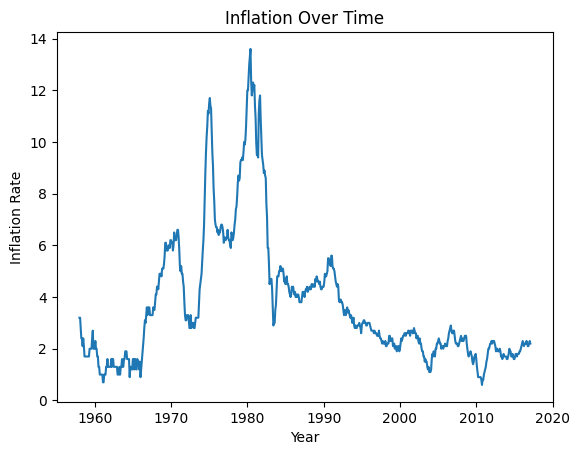

In [ ]:
sns.lineplot(
    data=df,
    x = 'Date',
    y='Inflation Rate'
)
plt.title('Inflation Over Time')
plt.xlabel('Year')
plt.ylabel('Inflation Rate')


In [ ]:
Min_Inflation = df[
    df['Inflation Rate'] == df['Inflation Rate'].min()
]
Min_Inflation

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
823,0.19,2.5,9.4,0.6,2010-10-01,0.125


In [ ]:
Max_Inflation = df[
    df['Inflation Rate'] == df['Inflation Rate'].max()
]
Max_Inflation

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
311,9.47,NaN,7.6,13.6,1980-06-01,NaN


###Unemployment

Text(0, 0.5, 'Unemployment Rate')

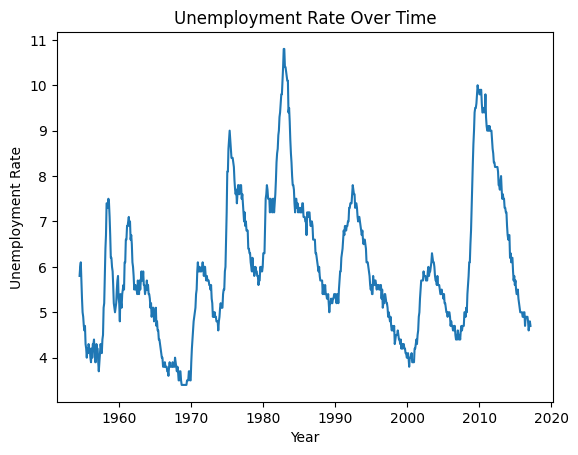

In [ ]:
sns.lineplot(
    data=df,
    x = 'Date',
    y='Unemployment Rate'
)
plt.title('Unemployment Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate')

In [ ]:
Min_unemployment = df[
    df['Unemployment Rate'] == df['Unemployment Rate'].min()
]
Min_unemployment

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
170,5.78,NaN,3.4,4.9,1968-09-01,NaN
171,5.91,1.8,3.4,4.8,1968-10-01,NaN
172,5.82,NaN,3.4,5.1,1968-11-01,NaN
173,6.02,NaN,3.4,5.1,1968-12-01,NaN
174,6.30,6.4,3.4,5.1,1969-01-01,NaN
175,6.61,NaN,3.4,5.3,1969-02-01,NaN
176,6.79,NaN,3.4,5.6,1969-03-01,NaN
177,7.41,1.3,3.4,6.1,1969-04-01,NaN
178,8.67,NaN,3.4,6.1,1969-05-01,NaN


In [ ]:
Max_unemployment = df[
    df['Unemployment Rate'] == df['Unemployment Rate'].max()
]
Max_unemployment

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
342,9.20,NaN,10.8,5.3,1982-11-01,9.5
344,8.95,NaN,10.8,4.5,1982-12-01,9.0


###Real GDP

Text(0, 0.5, 'Real GDP (Percent Change)')

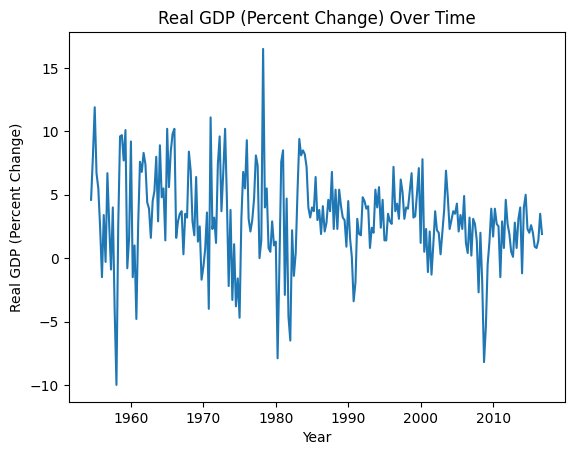

In [ ]:
sns.lineplot(
    data=df,
    x = 'Date',
    y='Real GDP (Percent Change)'
)
plt.title('Real GDP (Percent Change) Over Time')
plt.xlabel('Year')
plt.ylabel('Real GDP (Percent Change)')

In [ ]:
Min_GDP = df[
    df['Real GDP (Percent Change)'] == df['Real GDP (Percent Change)'].min()
]
Min_GDP

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
42,2.72,-10.0,5.8,3.2,1958-01-01,NaN


In [ ]:
Max_GDP = df[
    df['Real GDP (Percent Change)'] == df['Real GDP (Percent Change)'].max()
]
Max_GDP

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
285,6.89,16.5,6.1,6.5,1978-04-01,NaN


In [ ]:
GDP_below_zero = df[
    df['Real GDP (Percent Change)'] < 0
]
GDP_below_zero

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
18,2.45,-1.5,4.0,NaN,1956-01-01,NaN
24,2.75,-0.3,4.4,NaN,1956-07-01,NaN
33,3.00,-0.9,3.9,NaN,1957-04-01,NaN
39,3.50,-4.0,4.5,NaN,1957-10-01,NaN
42,2.72,-10.0,5.8,3.2,1958-01-01,NaN
60,3.47,-0.8,5.1,2.0,1959-07-01,NaN
69,3.92,-1.5,5.2,2.0,1960-04-01,NaN
75,2.47,-4.8,6.1,1.0,1960-10-01,NaN
183,9.00,-1.7,3.7,6.0,1969-10-01,NaN
186,8.98,-0.7,3.9,6.2,1970-01-01,NaN


In [ ]:
len(GDP_below_zero)

33

In [ ]:
GDP_below_zero['Date'].dt.year
GDP_below_zero['Date'].dt.year.value_counts().head(10)

,count
Date,
2008,3
1974,3
1956,2
1957,2
2001,2
2009,2
1980,2
1960,2
1981,2


###Interest Rates

Text(0, 0.5, 'Effective Federal Funds Rate')

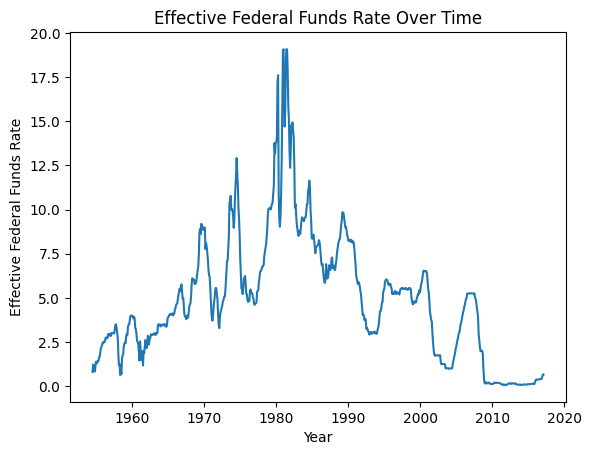

In [ ]:
sns.lineplot(
    data=df,
    x = 'Date',
    y='Effective Federal Funds Rate'
)
plt.title('Effective Federal Funds Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Effective Federal Funds Rate')

In [ ]:
Min_EFFR = df[
    df['Effective Federal Funds Rate'] == df['Effective Federal Funds Rate'].min()
]
Min_EFFR

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
832,0.07,0.8,9.0,1.8,2011-07-01,0.125
835,0.07,4.6,8.8,2.1,2011-10-01,0.125
837,0.07,NaN,8.5,2.2,2011-12-01,0.125
862,0.07,-1.2,6.6,1.6,2014-01-01,0.125
863,0.07,NaN,6.7,1.6,2014-02-01,0.125


In [ ]:
Max_EFFR = df[
    df['Effective Federal Funds Rate'] == df['Effective Federal Funds Rate'].max()
]
Max_EFFR

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
323,19.1,NaN,7.5,9.4,1981-06-01,NaN


###How do economic growth, unemployment, and inflation relate to Federal Reserve interest-rate policy?

In [ ]:
correlation_data = df[[
    'Effective Federal Funds Rate',
    'Real GDP (Percent Change)',
    'Unemployment Rate',
    'Inflation Rate'
]]

In [ ]:
correlation_matrix = correlation_data.corr()

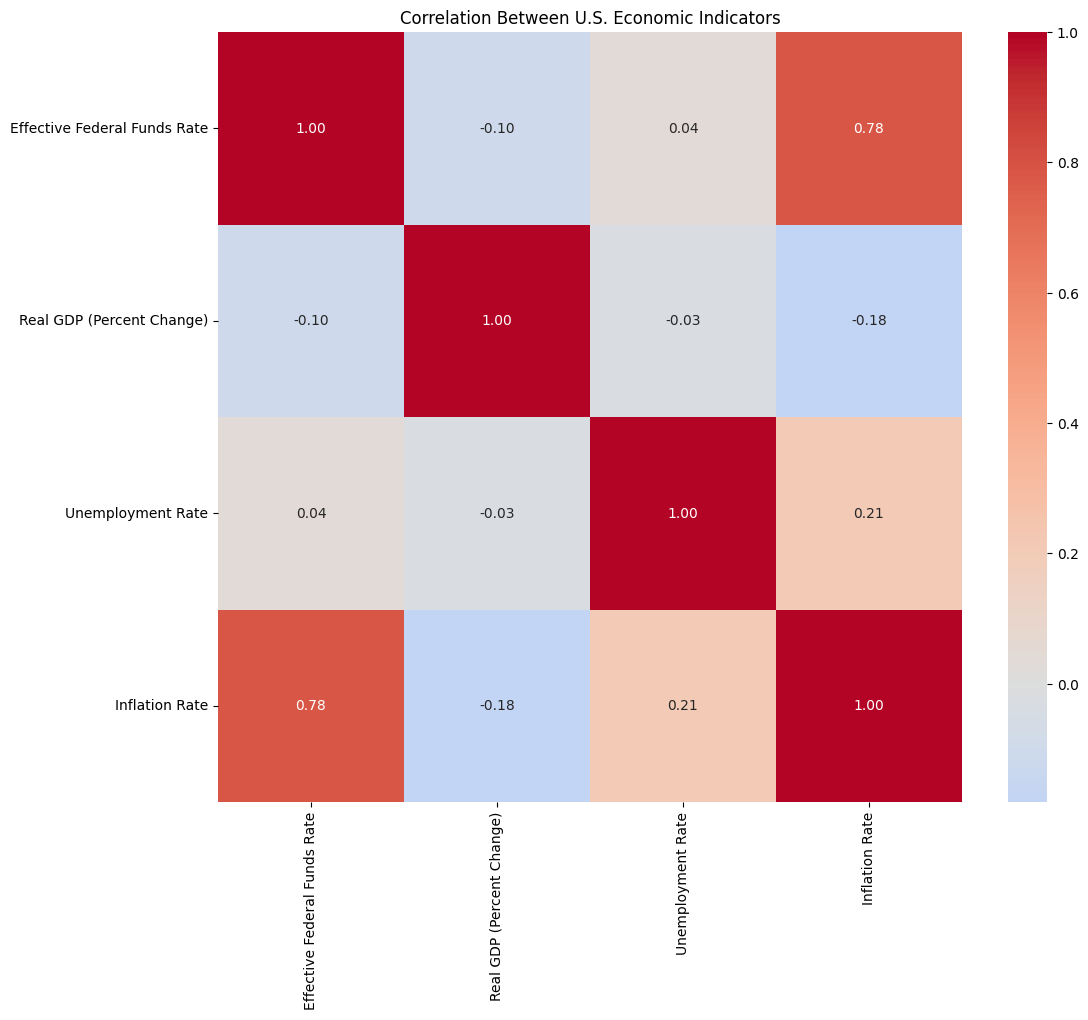

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title('Correlation Between U.S. Economic Indicators')
plt.show()

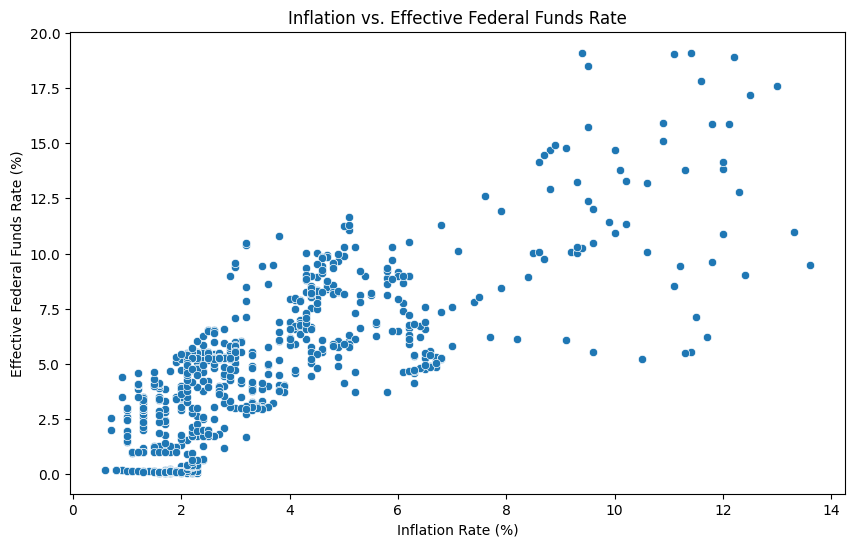

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Inflation Rate',
    y='Effective Federal Funds Rate'
)

plt.title('Inflation vs. Effective Federal Funds Rate')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Effective Federal Funds Rate (%)')
plt.show()

#SQL

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect('federal_reserve.db')

In [ ]:
df.to_sql(
    'economic_data',
    conn,
    if_exists='replace',
    index=False
)

904

In [ ]:
query = """
SELECT *
FROM economic_data
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date,Federal Funds Target Rate
0,0.80,4.6,5.8,None,1954-07-01 00:00:00,None
1,1.22,NaN,6.0,None,1954-08-01 00:00:00,None
2,1.06,NaN,6.1,None,1954-09-01 00:00:00,None
3,0.85,8.0,5.7,None,1954-10-01 00:00:00,None
4,0.83,NaN,5.3,None,1954-11-01 00:00:00,None


###Which 10 dates had the highest inflation rates in the dataset?

In [ ]:
query = """
SELECT Date, "Inflation Rate"
From economic_data
ORDER BY "Inflation Rate" DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,Date,Inflation Rate
0,1980-06-01 00:00:00,13.6
1,1980-05-01 00:00:00,13.3
2,1980-04-01 00:00:00,13.0
3,1980-03-01 00:00:00,12.5
4,1980-07-01 00:00:00,12.4
5,1980-10-01 00:00:00,12.3
6,1980-12-01 00:00:00,12.2
7,1980-11-01 00:00:00,12.1
8,1980-01-01 00:00:00,12.0
9,1980-02-01 00:00:00,12.0


###During periods of high inflation (8% or higher), what were the inflation rate and Effective Federal Funds Rate?

In [ ]:
query = """
SELECT Date, "Inflation Rate", "Effective Federal Funds Rate"
From economic_data
WHERE "Inflation Rate" >= 8
ORDER BY Date ASC;
"""
pd.read_sql_query(query, conn)

,Date,Inflation Rate,Effective Federal Funds Rate
0,1974-07-01 00:00:00,8.8,12.92
1,1974-08-01 00:00:00,9.6,12.01
2,1974-09-01 00:00:00,10.2,11.34
3,1974-10-01 00:00:00,10.6,10.06
4,1974-11-01 00:00:00,11.2,9.45
5,1974-12-01 00:00:00,11.1,8.53
6,1975-01-01 00:00:00,11.5,7.13
7,1975-02-01 00:00:00,11.7,6.24
8,1975-03-01 00:00:00,11.4,5.54
9,1975-04-01 00:00:00,11.3,5.49


###What was the average Effective Federal Funds Rate when inflation was 8% or higher?

In [ ]:
query = """
SELECT AVG("Effective Federal Funds Rate") AS Avg_EFFR
FROM economic_data
WHERE "Inflation Rate" >= 8;
"""
pd.read_sql_query(query, conn)

,Avg_EFFR
0,12.16661


###Which years had the most quarters of negative GDP growth?

In [75]:
query = """
SELECT
   strftime('%Y', Date) AS Year,
   COUNT("Real GDP (Percent Change)") AS GDP_Count
FROM economic_data
WHERE "Real GDP (Percent Change)" < 0
GROUP BY Year
ORDER BY GDP_Count DESC;
"""
pd.read_sql_query(query, conn)

,Year,GDP_Count
0,2008,3
1,1974,3
2,2009,2
3,2001,2
4,1982,2
5,1981,2
6,1980,2
7,1970,2
8,1960,2
9,1957,2


###What was the average Effective Federal Funds Rate during periods of high inflation (inflation ≥ 8%) compared with periods of lower inflation (inflation < 8%)?

In [ ]:
query = """
SELECT
  AVG("Effective Federal Funds Rate") AS AVG_EFFR,
  CASE
     WHEN "Inflation Rate" >= 8 THEN 'High Inflation'
     ELSE 'Lower Inflation'
  END AS Inflation_Category
FROM economic_data
WHERE "Inflation Rate" IS NOT NULL
GROUP BY Inflation_Category;
"""
pd.read_sql_query(query, conn)

,AVG_EFFR,Inflation_Category
0,12.166610,High Inflation
1,4.420553,Lower Inflation


###Identify periods where unemployment was 8% or higher, then return the Date and Unemployment Rate sorted from highest unemployment to lowest.

In [73]:
query = """
WITH High_Unemployment AS (
  SELECT
    Date,
    "Unemployment Rate"
  FROM economic_data
  WHERE "Unemployment Rate" >= 8)
SELECT *
FROM High_Unemployment
Order By "Unemployment Rate" DESC
"""
pd.read_sql_query(query, conn)

,Date,Unemployment Rate
0,1982-11-01 00:00:00,10.8
1,1982-12-01 00:00:00,10.8
2,1982-10-01 00:00:00,10.4
3,1983-01-01 00:00:00,10.4
4,1983-02-01 00:00:00,10.4
...,...,...
78,1975-01-01 00:00:00,8.1
79,1975-02-01 00:00:00,8.1
80,2012-08-01 00:00:00,8.1
81,1984-01-01 00:00:00,8.0


###Among high-unemployment periods (≥8%), what was the average Effective Federal Funds Rate?

In [74]:
query = """
WITH High_Unemployment AS (
  SELECT
    Date,
    "Unemployment Rate",
    "Effective Federal Funds Rate"
  FROM economic_data
  WHERE "Unemployment Rate" >= 8)
SELECT Avg("Effective Federal Funds Rate") AS Avg_EFFR
FROM High_Unemployment
Order By "Unemployment Rate" DESC
"""
pd.read_sql_query(query, conn)

,Avg_EFFR
0,4.428434


#Download Cleaned File

In [ ]:
df.to_csv('federal_reserve_cleaned.csv', index=False)

In [72]:
from google.colab import files

files.download('federal_reserve_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>